# Performance comparison: nMSE vs. MSE loss functions
This notebook is designed to evaluate and compare the performance of robotic dynamics models trained using different loss functions: nMSE and MSE.

* Generates total and per-joint training/validation loss curves to compare convergence stability.
* Includes a side-by-side bar chart comparison of test losses for each robot joint, highlighting which metric yields superior generalization.


In [21]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import glob
import os
import random
import torch
import re # regular expressions


import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [22]:
from google.colab import drive

In [23]:
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [24]:
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
!ls "/content/drive/MyDrive/NNDL_PROGETTO/data_generation/2dof/"

test_data  train_data  val_data


## NETWORK DEFINITION

In [26]:
class Net(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()

        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.out = nn.Linear(Nh2, No)
        self.act = nn.ReLU()

    def forward(self, x, additional_out=False):

        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x)
        return x

## Definizione classe PklDataset

In [27]:
import re
import glob
import os
import pandas as pd
import numpy as np
import random
from torch.utils.data import Dataset

class PklDataset(Dataset):
    """
    Dataset class to load and process robotic state data from pickle files.
    Expected data includes joint positions (q), velocities (dq),
    accelerations (ddq), and noiseless torques (tau).
    """
    def __init__(self, pkl_folder, random_choice=False, transform=None, normalize_y=False, conv_sin_cos=False):
        self.transform = transform
        self.normalize_y = normalize_y
        self.conv_sin_cos = conv_sin_cos

        # Extract Degrees of Freedom (DOF) from folder name using regex
        match = re.search(r"(\d+)dof", pkl_folder)
        if not match:
            raise ValueError(f"Unable to extract DOF from folder name: {pkl_folder}")
        self.n_dof = int(match.group(1))

        # Generate column names based on DOFn
        columns = [f"{prefix}_{j}" for j in range(1, self.n_dof+1) for prefix in ("q", "dq", "ddq")]
        columns += [f"tau_noiseless_{j}" for j in range(1, self.n_dof+1)]

        # Retrieve all pickle files in the specified directory
        pkl_files = glob.glob(os.path.join(pkl_folder, "*.pkl"))
        X_list, Y_list = [], []

        # Load data: either all files or a single random file
        if not random_choice:
            for file_path in pkl_files:
                df = pd.read_pickle(file_path)
                np_array = df[columns].to_numpy()
                # Split features (q, dq, ddq) from targets (tau)
                X_list.append(np_array[:, :(3*self.n_dof)])
                Y_list.append(np_array[:, (3*self.n_dof):])
        else:
            file_path = random.choice(pkl_files)
            df = pd.read_pickle(file_path)
            np_array = df[columns].to_numpy()
            X_list.append(np_array[:, :(3*self.n_dof)])
            Y_list.append(np_array[:, (3*self.n_dof):])

        # Concatenate all loaded data into single numpy arrays
        self.X = np.vstack(X_list)
        self.Y = np.vstack(Y_list)

        # Compute statistics for Y normalization (mean and standard deviation)
        self.mean_y = np.mean(self.Y, axis=0)
        self.std_y = np.std(self.Y, axis=0)
        # Prevent division by zero by setting zero-std to 1
        self.std_y[self.std_y == 0] = 1

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x, y = self.X[idx], self.Y[idx]

        # Trigonometric encoding for joint positions: maps q -> [sin(q), cos(q)]
        if self.conv_sin_cos:
            q   = x[0::3]       # Extract q components
            dq  = x[1::3]       # Extract dq components
            ddq = x[2::3]       # Extract ddq components

            # Efficiently build the output array: shape (4 * n_dof,)
            x_out = np.empty(4 * self.n_dof, dtype=np.float32)
            x_out[0::4] = np.sin(q)
            x_out[1::4] = np.cos(q)
            x_out[2::4] = dq
            x_out[3::4] = ddq
        else:
            x_out = x.astype(np.float32)

        y_out = y.astype(np.float32)

        # Apply normalization to the output targets if enabled
        if self.normalize_y:
            y_out = (y_out - self.mean_y) / self.std_y

        sample = (x_out, y_out)

        # Apply external transformations
        if self.transform:
            sample = self.transform(sample)

        return sample

In [28]:
class ToTensor(object):
    """Convert sample to Tensors."""

    def __call__(self, sample):
        # sample is expected to be a numpy array (a single row from the dataset)
        x = sample[0]
        y = sample[1]
        return (torch.tensor(x).float(),
                torch.tensor(y).float())

composed_transform = transforms.Compose([ToTensor()])

In [29]:
n_dof= 7

test_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/test_data/', transform=composed_transform)

In [30]:
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

In [31]:
# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training device: {device}")

Training device: cuda


In [32]:
# Initialize the network
torch.manual_seed(0)
Ni = (3*n_dof)
Nh1 = 128
Nh2 = 256
No = n_dof
net1 = Net(Ni, Nh1, Nh2, No)
net1.to(device)

Net(
  (fc1): Linear(in_features=21, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=7, bias=True)
  (act): ReLU()
)

In [33]:
# Initialize the network
torch.manual_seed(0)
Ni = (4*n_dof)
Nh1 = 128
Nh2 = 256
No = n_dof
net2 = Net(Ni, Nh1, Nh2, No)
net2.to(device)

Net(
  (fc1): Linear(in_features=28, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=7, bias=True)
  (act): ReLU()
)

## Loss function

In [34]:
# Define the loss function
loss_fn = nn.MSELoss(reduction='none')

def nmse_per_joint(outputs, targets, eps=1e-8):

  mse = loss_fn(outputs, targets)
  mse_per_joint = mse.mean(dim=0)

  var_per_joint = targets.var(dim=0, unbiased=False)
  nmse = mse_per_joint / (var_per_joint + eps)

  return nmse


In [35]:
def nmse_loss(outputs, targets):
  nmse = nmse_per_joint(outputs, targets)
  return nmse.mean()

In [36]:
# Define the optimizer
optimizer_1 = optim.Adam(net1.parameters(), lr=1e-3)
optimizer_2 = optim.Adam(net2.parameters(), lr=1e-3)

## Load Network



In [38]:
checkpoint = torch.load(f'/content/drive/MyDrive/NNDL_PROGETTO/models_normalized_mse/shallow/{n_dof}dof/checkpoint_epoch50.pt', weights_only=False)


net1.load_state_dict(checkpoint["model_state_dict"])
optimizer_1.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch_1 = checkpoint["epoch"] + 1# riparti dalla successiva
train_loss_log_1 = checkpoint["train_loss_log"]
val_loss_log_1 = checkpoint["val_loss_log"]
train_loss_joints_log_1 = checkpoint["train_loss_joints_log"]
val_loss_joints_log_1 = checkpoint["val_loss_joints_log"]

print(f"Riprendo da epoca {start_epoch_1}")

Riprendo da epoca 50


In [39]:
checkpoint = torch.load(f'/content/drive/MyDrive/NNDL_PROGETTO/models_sin_cos/shallow_network/{n_dof}dof/checkpoint_epoch50.pt', weights_only=False)

net2.load_state_dict(checkpoint["model_state_dict"])
optimizer_2.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch_2 = checkpoint["epoch"] + 1# riparti dalla successiva
train_loss_log_2 = checkpoint["train_loss_nmse_log"]
val_loss_log_2 = checkpoint["val_loss_nmse_log"]
train_loss_joints_log_2 = checkpoint["train_loss_joints_log"]
val_loss_joints_log_2 = checkpoint["val_loss_joints_log"]

print(f"Riprendo da epoca {start_epoch_2}")

Riprendo da epoca 50


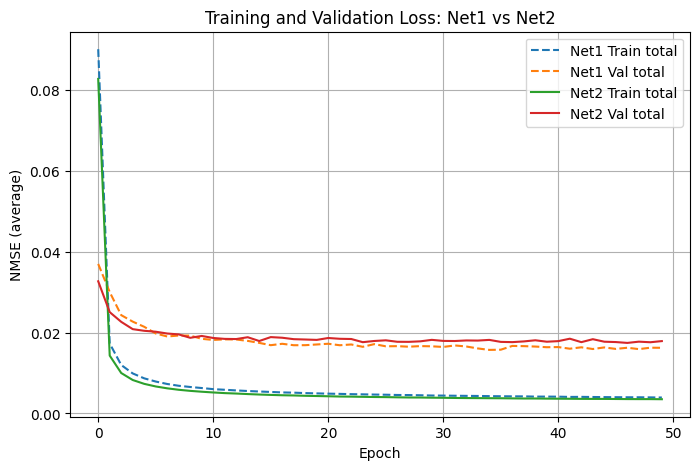

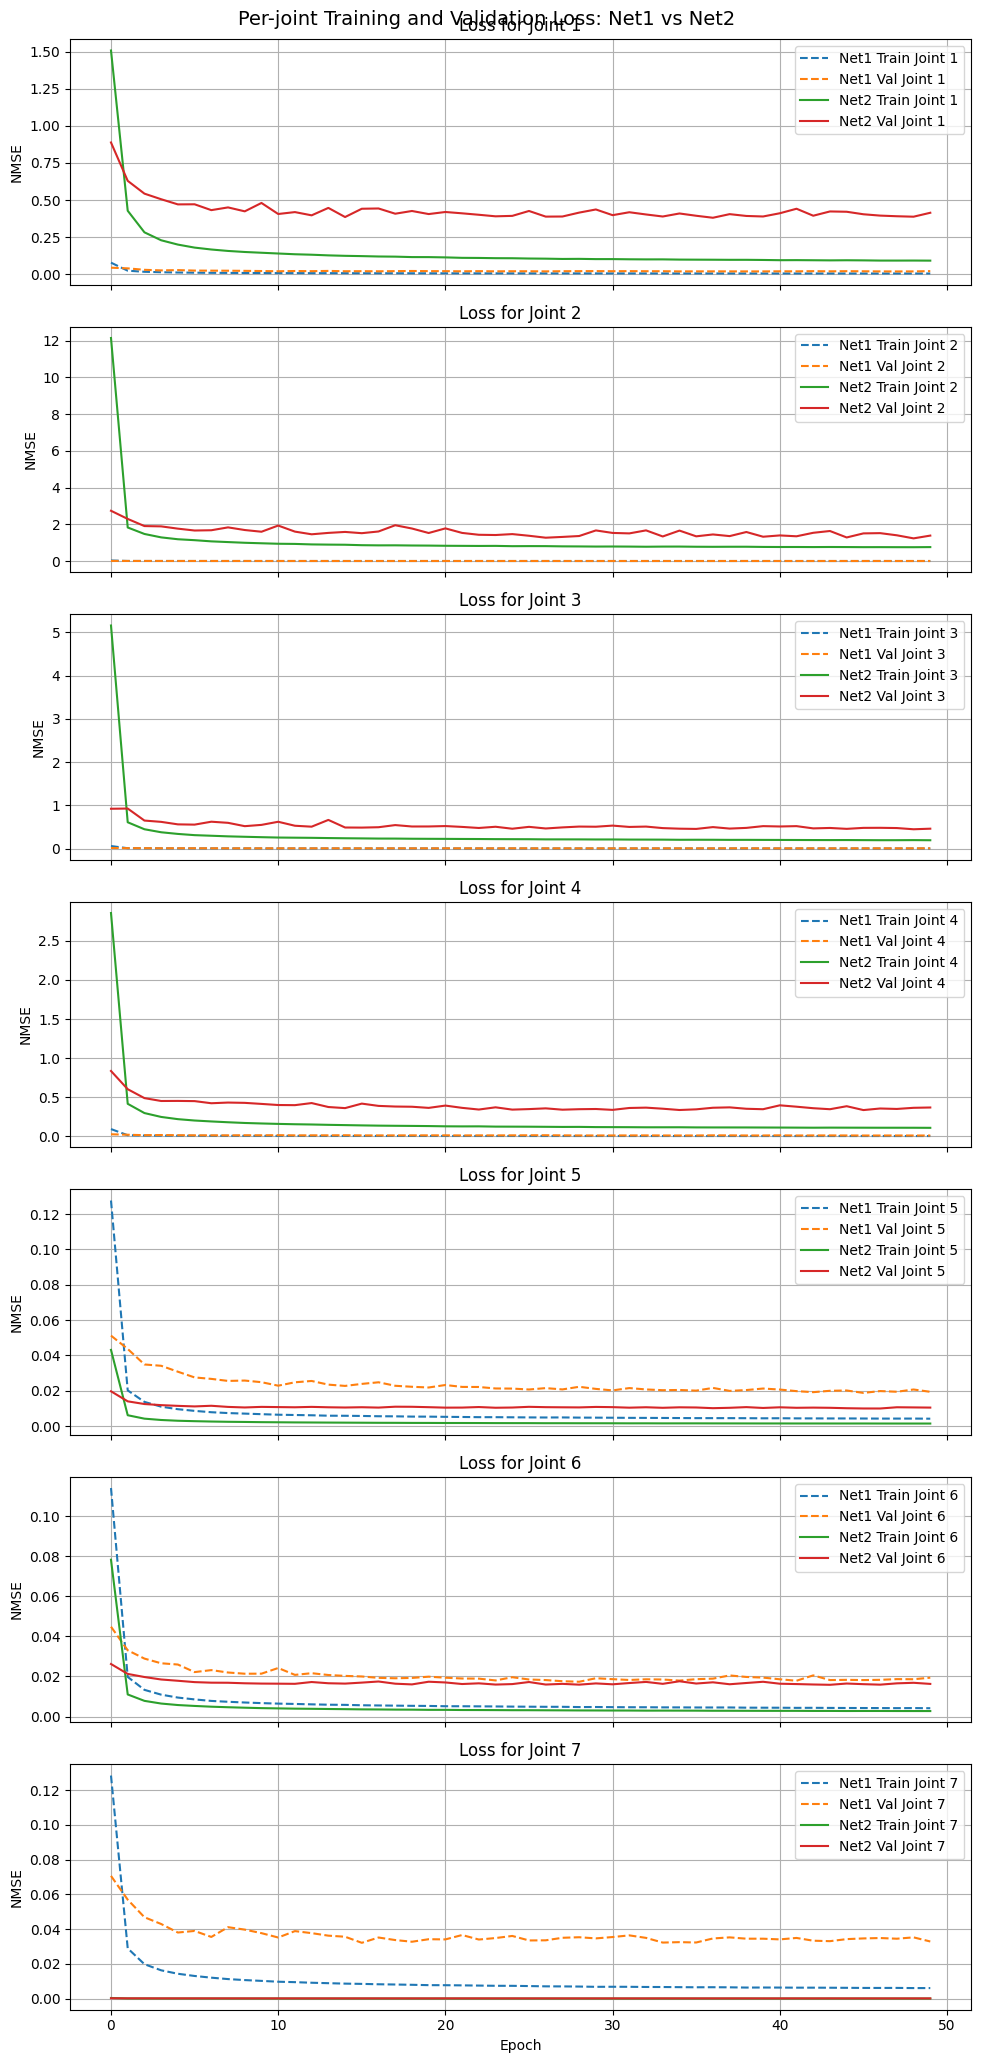

In [40]:
# Converting to numpy arrays
train_loss_log_1 = np.array(train_loss_log_1)
val_loss_log_1   = np.array(val_loss_log_1)
train_loss_joints_log_1 = np.array(train_loss_joints_log_1)
val_loss_joints_log_1   = np.array(val_loss_joints_log_1)

train_loss_log_2 = np.array(train_loss_log_2)
val_loss_log_2   = np.array(val_loss_log_2)
train_loss_joints_log_2 = np.array(train_loss_joints_log_2)
val_loss_joints_log_2   = np.array(val_loss_joints_log_2)

num_epochs_1 = len(train_loss_log_1)
num_epochs_2 = len(train_loss_log_2)
n_joints = train_loss_joints_log_1.shape[1]

# Total plotting
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs_1), train_loss_log_1, label="Net1 Train total", linestyle="--")
plt.plot(range(num_epochs_1), val_loss_log_1, label="Net1 Val total", linestyle="--")
plt.plot(range(num_epochs_2), train_loss_log_2, label="Net2 Train total")
plt.plot(range(num_epochs_2), val_loss_log_2, label="Net2 Val total")
plt.xlabel("Epoch")
plt.ylabel("NMSE (average)")
plt.title("Training and Validation Loss: Net1 vs Net2")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot per giunto ---
fig, axes = plt.subplots(n_joints, 1, figsize=(10, 3 * n_joints), sharex=True)

if n_joints == 1:
    axes = [axes]

for j in range(n_joints):
    axes[j].plot(range(num_epochs_1), train_loss_joints_log_1[:, j], label=f"Net1 Train Joint {j+1}", linestyle="--")
    axes[j].plot(range(num_epochs_1), val_loss_joints_log_1[:, j], label=f"Net1 Val Joint {j+1}", linestyle="--")
    axes[j].plot(range(num_epochs_2), train_loss_joints_log_2[:, j], label=f"Net2 Train Joint {j+1}")
    axes[j].plot(range(num_epochs_2), val_loss_joints_log_2[:, j], label=f"Net2 Val Joint {j+1}")
    axes[j].set_ylabel("NMSE")
    axes[j].legend()
    axes[j].grid(True)
    axes[j].set_title(f"Loss for Joint {j+1}")

axes[-1].set_xlabel("Epoch")

plt.suptitle("Per-joint Training and Validation Loss: Net1 vs Net2", fontsize=14)
plt.tight_layout()
plt.show()


In [41]:
# --- Estrazione e stampa dei valori finali ---

def print_final_metrics(name, total_train, total_val, joint_train, joint_val):
    n_joints = joint_train.shape[1]
    print(f"--- {name.upper()} FINAL METRICS ---")
    print(f"Total Train NMSE: {total_train[-1]:.6e}")
    print(f"Total Val NMSE:   {total_val[-1]:.6e}")
    print("-" * 30)
    for j in range(n_joints):
        print(f"Joint {j+1} | Train NMSE: {joint_train[-1, j]:.6e} | Val NMSE: {joint_val[-1, j]:.6e}")
    print("\n")

# Stampa per Net1
print_final_metrics("Net1", train_loss_log_1, val_loss_log_1,
                    train_loss_joints_log_1, val_loss_joints_log_1)

# Stampa per Net2
print_final_metrics("Net2", train_loss_log_2, val_loss_log_2,
                    train_loss_joints_log_2, val_loss_joints_log_2)

# --- Confronto Diretto (Delta) ---
print("--- COMPARISON: Net2 vs Net1 (Final Val Loss) ---")
delta_total = val_loss_log_2[-1] - val_loss_log_1[-1]
improvement = (delta_total / val_loss_log_1[-1]) * 100

print(f"Delta Total Val NMSE: {delta_total:+.6e} ({improvement:+.2f}%)")

for j in range(n_joints):
    d_j = val_loss_joints_log_2[-1, j] - val_loss_joints_log_1[-1, j]
    i_j = (d_j / val_loss_joints_log_1[-1, j]) * 100
    print(f"Joint {j+1} Delta Val: {d_j:+.6e} ({i_j:+.2f}%)")

--- NET1 FINAL METRICS ---
Total Train NMSE: 3.934962e-03
Total Val NMSE:   1.623493e-02
------------------------------
Joint 1 | Train NMSE: 5.196117e-03 | Val NMSE: 2.125639e-02
Joint 2 | Train NMSE: 1.722179e-03 | Val NMSE: 2.979590e-03
Joint 3 | Train NMSE: 2.699492e-03 | Val NMSE: 7.594083e-03
Joint 4 | Train NMSE: 3.475323e-03 | Val NMSE: 1.009021e-02
Joint 5 | Train NMSE: 4.244776e-03 | Val NMSE: 1.945149e-02
Joint 6 | Train NMSE: 4.148320e-03 | Val NMSE: 1.939287e-02
Joint 7 | Train NMSE: 6.058517e-03 | Val NMSE: 3.287982e-02


--- NET2 FINAL METRICS ---
Total Train NMSE: 3.515207e-03
Total Val NMSE:   1.789518e-02
------------------------------
Joint 1 | Train NMSE: 9.185881e-02 | Val NMSE: 4.143353e-01
Joint 2 | Train NMSE: 7.591782e-01 | Val NMSE: 1.384919e+00
Joint 3 | Train NMSE: 1.941943e-01 | Val NMSE: 4.613800e-01
Joint 4 | Train NMSE: 1.084240e-01 | Val NMSE: 3.685180e-01
Joint 5 | Train NMSE: 1.501132e-03 | Val NMSE: 1.052692e-02
Joint 6 | Train NMSE: 2.729898e-03 | V

## Comparative Performance Analysis: nMSE vs. MSE Architectures

In [42]:
# Mean and stdev for 7 DOF
mean_y = [8.67170465e-05, -1.33095930e+01, -7.05890699e-02, 1.37537737e+01,
          3.52697114e-01, 7.41195041e-01, 1.21108745e-03]

std_y = [4.44604269, 22.11200397, 8.81719514, 6.00121939,
         0.63659782, 0.85582398, 0.05492794]

mean_y_t = torch.tensor(mean_y, device=device)
std_y_t = torch.tensor(std_y, device=device)

=== NETWORK with metric NMSE===
AVERAGE TEST LOSS: 0.7858313918113708
TEST LOSS JOINTS: [0.43244997 0.2686456  0.39566272 0.5969839  1.3135931  0.8568744
 1.636612  ]

=== NETWORK with metric MSE ===
AVERAGE TEST LOSS: 0.7524086833000183
TEST LOSS JOINTS: [0.3020323  0.23276232 0.28679106 0.61027604 1.5132724  0.8900292
 1.4316983 ]


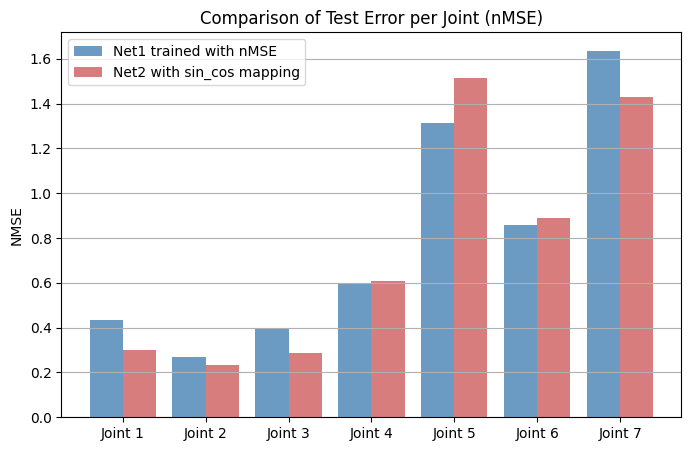

In [46]:
def evaluate_network(net, test_dataloader, device, is_sin_cos=False, was_trained_normalized=False):
    """
    Funzione per valutare una rete su test set.
    Ritorna outputs, labels, test_loss medio e per giunto.
    """
    all_inputs = []
    all_outputs = []
    all_labels = []
    test_loss = []
    test_loss_joints = []

    net.eval()  # Evaluation mode (e.g. disable dropout)
    with torch.no_grad():  # Disable gradient tracking
        for sample_batched in test_dataloader:
            # Move data to device
            x_raw = sample_batched[0].to(device)
            if is_sin_cos:
                # 1. Calcolo numero di giunti (assumendo layout 3*n_dof)
                n_joints = x_raw.shape[1] // 3

                # 2. Estrazione componenti (layout interleaved: q1, dq1, ddq1, q2...)
                q   = x_raw[:, 0::3]
                dq  = x_raw[:, 1::3]
                ddq = x_raw[:, 2::3]

                # 3. Allocazione tensore trasformato (dimensione batch, 4*n_joints)
                x_batch = torch.empty((x_raw.shape[0], 4 * n_joints), device=device)

                # 4. Riempimento interleaved [sin(q), cos(q), dq, ddq]
                x_batch[:, 0::4] = torch.sin(q)
                x_batch[:, 1::4] = torch.cos(q)
                x_batch[:, 2::4] = dq
                x_batch[:, 3::4] = ddq
            else:
                x_batch = x_raw

            label_batch = sample_batched[1].to(device)

            # Forward pass
            out = net(x_batch)

            # Denormalizzazione (SE la rete è stata allenata su y normalizzati)
            if was_trained_normalized:
              out = out * std_y_t + mean_y_t

            # Loss
            loss = nmse_loss(out, label_batch)
            loss_per_joints = nmse_per_joint(out, label_batch)

            # Save val loss for this batch
            test_loss.append(loss.cpu().numpy())
            test_loss_joints.append(loss_per_joints.cpu().numpy())

            # Save outputs and labels
            all_inputs.append(x_batch)
            all_outputs.append(out)
            all_labels.append(label_batch)

    # Concatenate all the outputs and labels in a single tensor
    all_inputs  = torch.cat(all_inputs)
    all_outputs = torch.cat(all_outputs)
    all_labels  = torch.cat(all_labels)

    # Media totale e per giunto
    test_loss = np.mean(test_loss)
    test_loss_joints = np.mean(np.vstack(test_loss_joints), axis=0)

    return all_inputs, all_outputs, all_labels, test_loss, test_loss_joints


# --- Valutazione rete NMSE ---
inputs_nmse, outputs_nmse, labels_nmse, test_loss_nmse, test_loss_joints_nmse = evaluate_network(net1, test_dataloader, device, was_trained_normalized = True)
print("=== NETWORK with metric NMSE===")
print(f"AVERAGE TEST LOSS: {test_loss_nmse}")
print(f"TEST LOSS JOINTS: {test_loss_joints_nmse}")

# --- Valutazione rete sin_cos ---
inputs_mse, outputs_mse, labels_mse, test_loss_mse, test_loss_joints_mse = evaluate_network(net2, test_dataloader, device, is_sin_cos=True, was_trained_normalized=True)
print("\n=== NETWORK with metric MSE ===")
print(f"AVERAGE TEST LOSS: {test_loss_mse}")
print(f"TEST LOSS JOINTS: {test_loss_joints_mse}")


# --- Confronto grafico per giunto ---
n_joints = test_loss_joints_nmse.shape[0]
x = np.arange(n_joints)

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, test_loss_joints_nmse, width=0.4, label="Net1 trained with nMSE", alpha=0.8, color='steelblue')
plt.bar(x + 0.2, test_loss_joints_mse, width=0.4, label="Net2 with sin_cos mapping", alpha=0.8, color='indianred')
plt.xticks(x, [f"Joint {i+1}" for i in range(n_joints)])
plt.ylabel("NMSE")
plt.title("Comparison of Test Error per Joint (nMSE)")
plt.legend()
plt.grid(True, axis="y")
plt.show()



=== NETWORK 1 - Evaluation (MSE) ===
AVERAGE TEST MSE: 4.453556e-01
MSE PER JOINTS: [4.72472250e-01 1.55015159e+00 6.65733874e-01 4.05727327e-01
 8.36999249e-03 1.49225956e-02 1.13389964e-04]

=== NETWORK 2 - Evaluation (MSE) ===
AVERAGE TEST MSE: 3.962130e-01
MSE PER JOINTS: [4.5598948e-01 1.4012350e+00 4.9247408e-01 3.9941666e-01 9.5853917e-03
 1.4661603e-02 1.2812148e-04]


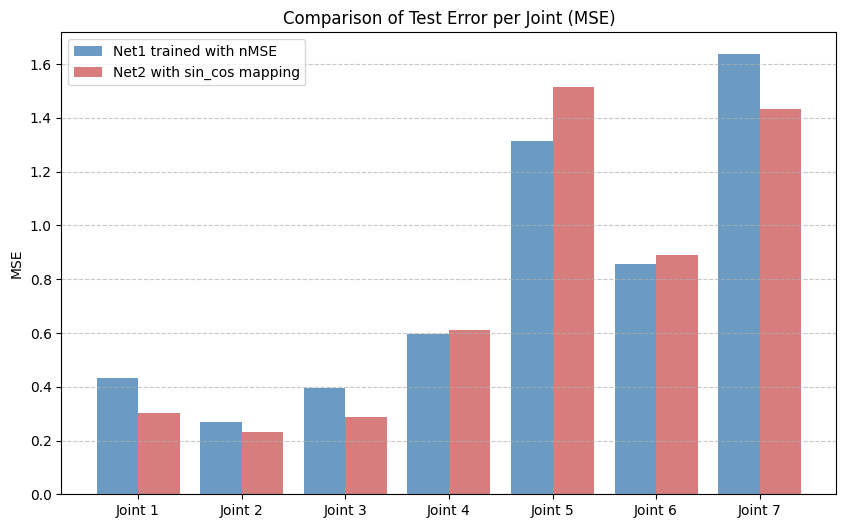

In [47]:
import torch.nn.functional as F

def evaluate_network_mse(net, test_dataloader, device, was_trained_normalized=True, is_sin_cos=False):
    """
    Funzione per valutare una rete su test set utilizzando la metrica MSE.
    Ritorna outputs, labels, MSE medio totale e MSE per singolo giunto.
    """
    all_inputs = []
    all_outputs = []
    all_labels = []
    test_loss_batches = []
    test_loss_joints_batches = []

    net.eval()  # Modalità valutazione
    with torch.no_grad():
        for sample_batched in test_dataloader:
            x_raw = sample_batched[0].to(device)
            if is_sin_cos:
                # 1. Calcolo numero di giunti (assumendo layout 3*n_dof)
                n_joints = x_raw.shape[1] // 3

                # 2. Estrazione componenti (layout interleaved: q1, dq1, ddq1, q2...)
                q   = x_raw[:, 0::3]
                dq  = x_raw[:, 1::3]
                ddq = x_raw[:, 2::3]

                # 3. Allocazione tensore trasformato (dimensione batch, 4*n_joints)
                x_batch = torch.empty((x_raw.shape[0], 4 * n_joints), device=device)

                # 4. Riempimento interleaved [sin(q), cos(q), dq, ddq]
                x_batch[:, 0::4] = torch.sin(q)
                x_batch[:, 1::4] = torch.cos(q)
                x_batch[:, 2::4] = dq
                x_batch[:, 3::4] = ddq
            else:
                x_batch = x_raw

            label_batch = sample_batched[1].to(device)

            # Forward pass
            out = net(x_batch)

            # Denormalizzazione (SE la rete è stata allenata su y normalizzati)
            if was_trained_normalized:
              out = out * std_y_t + mean_y_t

            # --- Calcolo MSE Totale del batch ---
            # Utilizza la funzione nativa di PyTorch per la media quadratica
            loss = F.mse_loss(out, label_batch)

            # --- Calcolo MSE per Giunto del batch ---
            # (out - label)**2 calcola l'errore quadrato elemento per elemento
            # .mean(dim=0) media lungo la dimensione del batch, restituendo un valore per ogni giunto
            loss_per_joints = torch.mean((out - label_batch)**2, dim=0)

            test_loss_batches.append(loss.cpu().numpy())
            test_loss_joints_batches.append(loss_per_joints.cpu().numpy())

            all_inputs.append(x_batch)
            all_outputs.append(out)
            all_labels.append(label_batch)

    # Concatenazione dei risultati
    all_inputs  = torch.cat(all_inputs)
    all_outputs = torch.cat(all_outputs)
    all_labels  = torch.cat(all_labels)

    # Media finale calcolata su tutti i batch
    test_loss_total = np.mean(test_loss_batches)
    test_loss_joints = np.mean(np.vstack(test_loss_joints_batches), axis=0)

    return all_inputs, all_outputs, all_labels, test_loss_total, test_loss_joints


# --- Valutazione Modello 1 (ex NMSE) ---
inputs_1, outputs_1, labels_1, mse_total_1, mse_joints_1 = evaluate_network_mse(net1, test_dataloader, device)
print("=== NETWORK 1 - Evaluation (MSE) ===")
print(f"AVERAGE TEST MSE: {mse_total_1:.6e}")
print(f"MSE PER JOINTS: {mse_joints_1}")

# --- Valutazione Modello 2 (ex MSE) ---
inputs_2, outputs_2, labels_2, mse_total_2, mse_joints_2 = evaluate_network_mse(net2, test_dataloader, device, is_sin_cos=True)
print("\n=== NETWORK 2 - Evaluation (MSE) ===")
print(f"AVERAGE TEST MSE: {mse_total_2:.6e}")
print(f"MSE PER JOINTS: {mse_joints_2}")


# --- Confronto grafico basato su MSE ---
n_joints = mse_joints_1.shape[0]
x = np.arange(n_joints)

plt.figure(figsize=(10, 6))
# Plot delle barre per il confronto dell'errore assoluto (MSE)
plt.bar(x - 0.2, test_loss_joints_nmse, width=0.4, label="Net1 trained with nMSE", alpha=0.8, color='steelblue')
plt.bar(x + 0.2, test_loss_joints_mse, width=0.4, label="Net2 with sin_cos mapping", alpha=0.8, color='indianred')

plt.xticks(x, [f"Joint {i+1}" for i in range(n_joints)])
plt.ylabel("MSE")
plt.title("Comparison of Test Error per Joint (MSE)")
plt.legend()
plt.grid(True, axis="y", linestyle='--', alpha=0.7)
plt.show()